# House Price Prediction — Model Notebook

End-to-end notebook: load the raw Kaggle dataset, clean and engineer features, explore the
data, train and compare several regression models, and export the winning model + supporting
files for the FastAPI backend.


## 2.1 — Load & Inspect

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import time
import pandas as pd
df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape) # how many rows/columns? 


Shape: (187531, 21)


### Initial inspection
The dataset has **187,531 rows and 21 columns**. Numeric-looking columns are actually stored
as text (`Amount(in rupees)`, `Carpet Area`, `Floor`, etc.) and need parsing. The columns with
the most missing values are `Plot Area` and `Dimensions` (100% missing), followed by `Society`
(~58%), `Super Area` (~57%), and `Car Parking` (~55%) — this is why they get dropped or
carefully imputed below.

In [2]:
df.head()  


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()    # dtypes, missing values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe() 


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False) # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Title                0.000000
location             0.000000
Amount(in rupees)    0.000000
Index                0.000000
dtype: float64

## 2.3 — Cleaning & Feature Engineering

### Dropping mostly-empty / useless columns
`Dimensions` and `Plot Area` are 100% missing (see the missing-value scan above), and `Index`,
`Title`, `Description` carry no predictive information — all five are dropped immediately.

In [6]:
df = df.drop(columns=["Dimensions", "Plot Area", "Index", "Title", "Description"])
df.shape

(187531, 16)

### Parsing the price (`Amount(in rupees)` → `price_clean`)
Price is stored as free text like `"42 Lac"` or `"1.2 Cr"`. `parse_amount` converts these to a
plain numeric rupee value (1 Lac = 100,000; 1 Cr = 10,000,000) and rows that can't be parsed
(e.g. `"Call for Price"`) are dropped, since they have no usable target value.

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df[["Amount(in rupees)", "price_clean"]].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


After parsing `Amount(in rupees)` (converting "Lac"/"Cr" strings to numeric rupees) and
dropping unparseable rows, **177,847 of 187,531 rows remain**. The price distribution is
extremely right-skewed (mean ₹12M vs. median ₹7.8M, max ₹14B), confirming the need for a
log scale in EDA and outlier capping before modeling.

In [8]:
print("Rows remaining:", df.shape[0])
df["price_clean"].describe()

Rows remaining: 177847


count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

### Parsing carpet area (`Carpet Area` → `carpet_area_sqft`)
Area is stored as text like `"1200 sqft"` or `"140 sqm"`. `parse_area` extracts the numeric
value and converts square meters to square feet (1 sqm ≈ 10.764 sqft) so every row is on the
same unit.

In [9]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"[\d,.]+", x)
    if not match:
        return None
    value = float(match.group().replace(",", ""))
    if "sqm" in x:
        value = value * 10.764   # convert sqm to sqft
    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df[["Carpet Area", "carpet_area_sqft"]].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


`carpet_area_sqft` had implausible values (max ~709,222 sqft), so rows outside **100–10,000 sqft**
are dropped as data-entry errors. `price_clean` is capped at the **1st/99th percentile**
rather than dropped, to keep the rows but reduce the influence of extreme mansions/data errors.
This leaves **175,923 rows**.

In [10]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

In [11]:
df.shape

(177847, 18)

### Parsing floor (`Floor` → `floor_num`)
Floor is text like `"3 out of 10"`, `"Ground out of 5"`, or `"Basement"`. `parse_floor` extracts
just the unit's own floor number, mapping `Ground` → 0 and `Basement` → -1.

In [12]:
df["Floor"].value_counts().head(20)

Floor
1 out of 4          11801
2 out of 4          11437
3 out of 4           7804
1 out of 3           6934
2 out of 3           5868
4 out of 4           5814
3 out of 3           4405
2 out of 5           4331
4 out of 5           3723
3 out of 6           3579
3 out of 5           3360
2 out of 2           3350
1 out of 5           3319
1 out of 2           2829
Ground out of 4      2778
5 out of 5           2405
8 out of 10          2381
Ground out of 10     2154
3 out of 10          1967
4 out of 8           1888
Name: count, dtype: int64

In [13]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    floor_part = x.split("out of")[0].strip()
    if "ground" in floor_part:
        return 0
    if "basement" in floor_part:
        return -1
    match = re.search(r"\d+", floor_part)
    if match:
        return int(match.group())
    return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df[["Floor", "floor_num"]].head(10)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [14]:
df["floor_num"].value_counts().sort_index().head(20)
df["floor_num"].isna().sum()  

np.int64(6949)

### Parsing bathroom, balcony, and car parking counts
`Bathroom`, `Balcony`, and `Car Parking` all use the same `"N"` / `">N"` text pattern. A shared
helper (`parse_numeric_with_gt` / `parse_parking_count`) extracts the number, treating `">N"`
as `N + 1`. `Car Parking` additionally encodes whether the spot is Covered or Open, split out
into a separate `parking_type` column.

In [15]:
print(df["Bathroom"].value_counts().head(10))
print()
print(df["Balcony"].value_counts().head(10))
print()
print(df["Car Parking"].value_counts().head(10))

Bathroom
2       88999
3       54187
1       15509
4       14826
5        3281
6         187
7          32
> 10       29
8          14
10         12
Name: count, dtype: int64

Balcony
2       50311
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
Name: count, dtype: int64

Car Parking
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
Name: count, dtype: int64


In [16]:
def parse_parking_count(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.startswith(">"):
        num = re.search(r"\d+", x)
        return int(num.group()) + 1 if num else None
    match = re.search(r"\d+", x)
    return int(match.group()) if match else None

def parse_parking_type(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    if "covered" in x:
        return "Covered"
    if "open" in x:
        return "Open"
    return None

df["parking_count"] = df["Car Parking"].apply(parse_parking_count)
df["parking_type"] = df["Car Parking"].apply(parse_parking_type)

df[["Car Parking", "parking_count", "parking_type"]].head(10)

,Car Parking,parking_count,parking_type
0,NaN,NaN,None
1,1 Open,1.0,Open
2,1 Covered,1.0,Covered
3,NaN,NaN,None
4,1 Covered,1.0,Covered
5,NaN,NaN,None
6,NaN,NaN,None
7,NaN,NaN,None
8,NaN,NaN,None
9,1 Covered,1.0,Covered


In [17]:
def parse_numeric_with_gt(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.startswith(">"):
        num = re.search(r"\d+", x)
        return int(num.group()) + 1 if num else None
    match = re.search(r"\d+", x)
    return int(match.group()) if match else None

df["bathroom_num"] = df["Bathroom"].apply(parse_numeric_with_gt)
df["balcony_num"] = df["Balcony"].apply(parse_numeric_with_gt)

df[["Bathroom", "bathroom_num", "Balcony", "balcony_num"]].head(10)

,Bathroom,bathroom_num,Balcony,balcony_num
0,1,1.0,2,2.0
1,2,2.0,NaN,NaN
2,2,2.0,NaN,NaN
3,1,1.0,1,1.0
4,2,2.0,NaN,NaN
5,1,1.0,1,1.0
6,1,1.0,NaN,NaN
7,1,1.0,NaN,NaN
8,1,1.0,NaN,NaN
9,3,3.0,1,1.0


In [18]:
print(df["bathroom_num"].value_counts().sort_index())
print(df["balcony_num"].value_counts().sort_index())

bathroom_num
1.0     15509
2.0     88999
3.0     54187
4.0     14826
5.0      3281
6.0       187
7.0        32
8.0        14
9.0        11
10.0       12
11.0       29
Name: count, dtype: int64
balcony_num
1.0     45145
2.0     50311
3.0     24958
4.0      9275
5.0       814
6.0       127
7.0        14
8.0        13
9.0         2
10.0       13
11.0       16
Name: count, dtype: int64


### Handling high-cardinality location & society columns
`location` has thousands of unique values, which would blow up one-hot encoding. Only the
**top 50** most common locations are kept as their own category; every other location is
grouped into `"other"`. `Society` (58% missing, also high-cardinality) is dropped entirely.

In [19]:
print("Unique locations:", df["location"].nunique())
print("Unique Society:", df["Society"].nunique())
df["location"].value_counts().head(15)

Unique locations: 81
Unique Society: 10068


location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
Name: count, dtype: int64

In [20]:
top_n = 50
top_locations = df["location"].value_counts().nlargest(top_n).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

df = df.drop(columns=["Society"])

df["location_grouped"].value_counts().tail(10)

location_grouped
agra           443
mangalore      442
bhubaneswar    392
siliguri       389
badlapur       388
panchkula      330
guntur         268
varanasi       267
nashik         244
thrissur       206
Name: count, dtype: int64

In [21]:
df["location_grouped"].value_counts().get("other", 0)

np.int64(2992)

In [22]:
df["location_grouped"].nunique()

51

### Dropping now-redundant raw columns
Now that clean numeric/categorical versions exist (`price_clean`, `carpet_area_sqft`,
`floor_num`, `bathroom_num`, `balcony_num`, `parking_count`, `parking_type`,
`location_grouped`), the original raw text columns they were derived from are dropped.

In [23]:
df = df.drop(columns=[
    "location", "Floor", "Bathroom", "Balcony", "Car Parking",
    "Carpet Area", "Amount(in rupees)", "Price (in rupees)"
])
df.shape

(177847, 15)

### Removing outliers

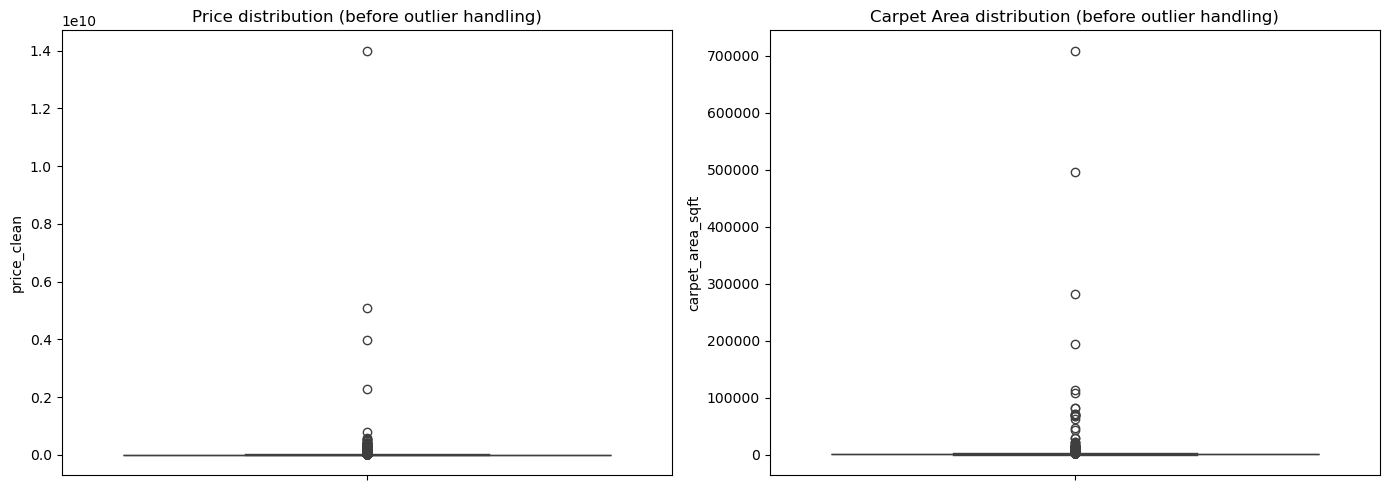

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64
count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(y=df["price_clean"], ax=axes[0])
axes[0].set_title("Price distribution (before outlier handling)")

sns.boxplot(y=df["carpet_area_sqft"], ax=axes[1])
axes[1].set_title("Carpet Area distribution (before outlier handling)")

plt.tight_layout()
plt.show()

print(df["price_clean"].describe())
print(df["carpet_area_sqft"].describe())

**Comment:** The boxplots confirm heavy outlier presence on the raw scale — both `price_clean`
and `carpet_area_sqft` show long tails of extreme values well above the box, which is exactly
why the outlier-capping step below (1st/99th percentile for price, sqft range filter for area)
is necessary before modeling.


In [25]:
# Drop clearly-impossible carpet areas (data entry errors)
df = df[(df["carpet_area_sqft"].isna()) | ((df["carpet_area_sqft"] >= 100) & (df["carpet_area_sqft"] <= 10000))]

# Cap price at 1st/99th percentile instead of dropping rows
low, high = df["price_clean"].quantile([0.01, 0.99])
df["price_clean"] = df["price_clean"].clip(lower=low, upper=high)

print(df.shape)
df[["price_clean", "carpet_area_sqft"]].describe()

(175923, 15)


,price_clean,carpet_area_sqft
count,1.759230e+05,99598.000000
mean,1.168422e+07,1227.454059
std,1.132773e+07,722.769119
min,1.600000e+06,100.000000
25%,5.000000e+06,800.000000
50%,7.800000e+06,1060.000000
75%,1.480000e+07,1500.000000
max,7.000000e+07,10000.000000


### Inspecting remaining categorical columns
A quick scan of the remaining categorical columns' value counts, to check for typos, rare
categories, or columns (like `Status`) that don't carry useful signal.

In [26]:
for col in ["Status", "Transaction", "Ownership", "facing", "overlooking", "Furnishing"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().head(8))
    print()

--- Status ---
Status
Ready to Move    175330
Name: count, dtype: int64

--- Transaction ---
Transaction
Resale          133767
New Property     41384
Other              703
Rent/Lease           2
Name: count, dtype: int64

--- Ownership ---
Ownership
Freehold                105415
Leasehold                 5142
Co-operative Society      3340
Power Of Attorney         1003
Name: count, dtype: int64

--- facing ---
facing
East            52147
North - East    23327
North           14452
West             8454
South            4304
North - West     3797
South - East     2565
South -West      2050
Name: count, dtype: int64

--- overlooking ---
overlooking
Main Road                       28793
Garden/Park, Main Road          26312
Garden/Park                     22797
Garden/Park, Pool, Main Road    12275
Pool, Garden/Park, Main Road     3400
Garden/Park, Pool                2837
Main Road, Garden/Park, Pool     1353
Pool, Main Road                  1130
Name: count, dtype: int64

--- Furni

In [27]:
df = df.drop(columns=["Status"])
df.shape

(175923, 14)

### Encoding `overlooking` into binary flags
`overlooking` is a free-text, multi-value field (e.g. `"Main Road, Garden/Park"`). Rather than
one-hot encoding the raw text, it's split into three independent binary flags —
`overlooks_main_road`, `overlooks_garden_park`, `overlooks_pool` — since a listing can overlook
more than one of these at once.

In [28]:
df["overlooking"] = df["overlooking"].fillna("")

df["overlooks_main_road"] = df["overlooking"].str.contains("Main Road").astype(int)
df["overlooks_garden_park"] = df["overlooking"].str.contains("Garden/Park", regex=False).astype(int)
df["overlooks_pool"] = df["overlooking"].str.contains("Pool").astype(int)

df = df.drop(columns=["overlooking"])

df[["overlooks_main_road", "overlooks_garden_park", "overlooks_pool"]].sum()

overlooks_main_road      73981
overlooks_garden_park    70100
overlooks_pool           22477
dtype: int64

In [29]:
df.isna().mean().sort_values(ascending=False)

Super Area               0.566657
parking_count            0.534836
parking_type             0.534836
carpet_area_sqft         0.433855
facing                   0.368496
Ownership                0.346873
balcony_num              0.267930
floor_num                0.039483
Furnishing               0.011744
bathroom_num             0.004320
Transaction              0.000381
price_clean              0.000000
location_grouped         0.000000
overlooks_main_road      0.000000
overlooks_garden_park    0.000000
overlooks_pool           0.000000
dtype: float64

In [30]:
df.columns.tolist()

['Transaction',
 'Furnishing',
 'facing',
 'Ownership',
 'Super Area',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'parking_count',
 'parking_type',
 'bathroom_num',
 'balcony_num',
 'location_grouped',
 'overlooks_main_road',
 'overlooks_garden_park',
 'overlooks_pool']

## 2.2 — Exploratory Data Analysis (EDA)
Four required plots (target distribution, price vs. area, price by top locations, price by
furnishing/bathrooms) plus several additional plots for a fuller picture of the cleaned data.

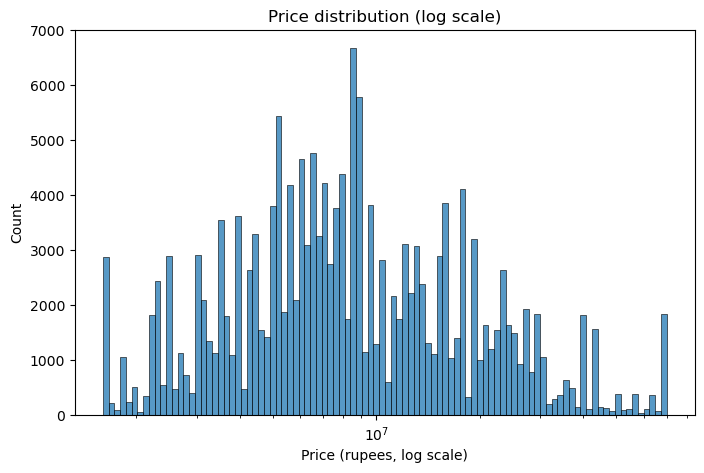

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (rupees, log scale)")
plt.show()

**Comment:** Price is heavily right-skewed on a linear scale; the log-scale view confirms it's
close to log-normal, which is why the guide's tip about training on `log1p(price)` is worth
testing as a follow-up improvement.

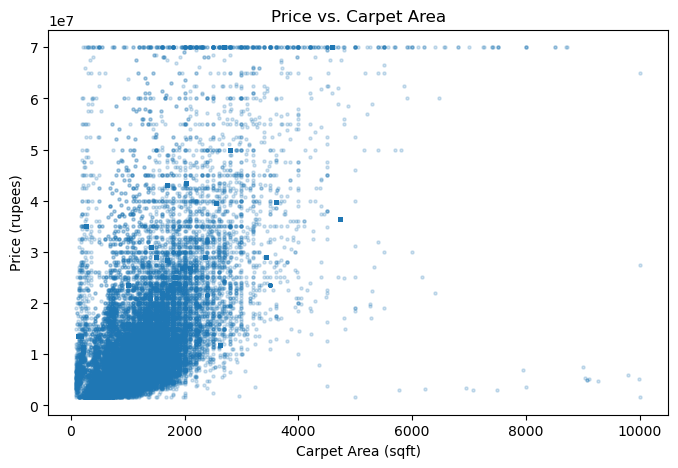

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.2, s=5)
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (rupees)")
plt.show()

**Comment:** Price rises with carpet area but with wide variance at every area level — location
and amenities clearly matter as much as size, which the correlation heatmap later confirms
(carpet area alone isn't the dominant driver).

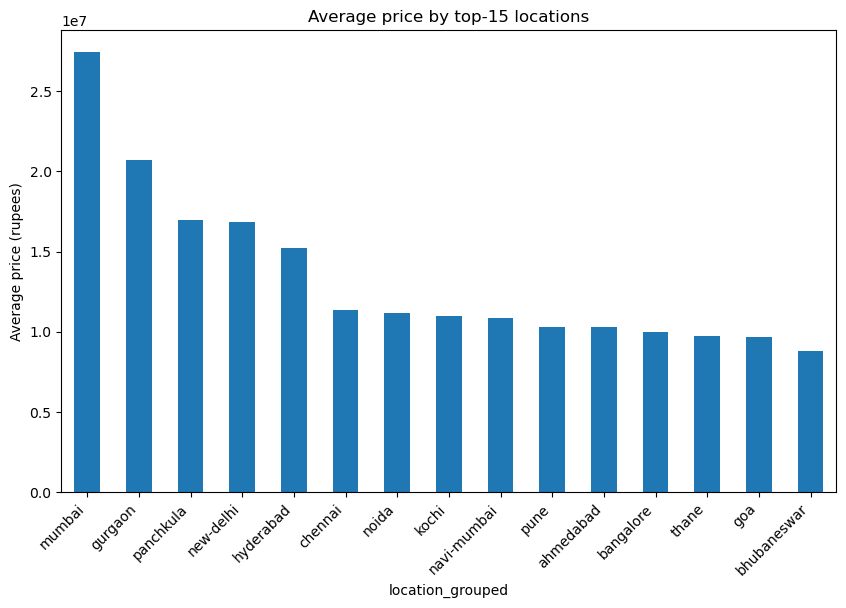

In [33]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top15.plot(kind="bar")
plt.title("Average price by top-15 locations")
plt.ylabel("Average price (rupees)")
plt.xticks(rotation=45, ha="right")
plt.show()

**Comment:** Average price varies enormously by location — a multi-fold difference between the
most and least expensive of the top 15 — showing `location_grouped` is a critical predictive
feature, consistent with the top-50 grouping strategy used above.

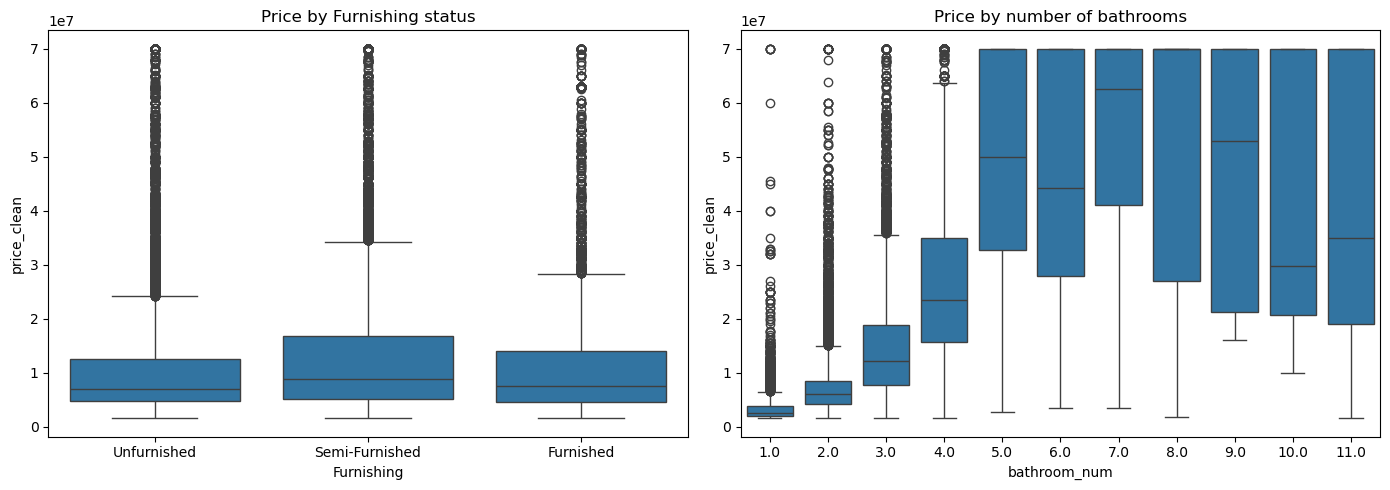

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_title("Price by Furnishing status")

sns.boxplot(data=df, x="bathroom_num", y="price_clean", ax=axes[1])
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

**Comment:** Fully furnished properties command a visibly higher median price than unfurnished
ones, and price increases steadily with bathroom count — both align with intuition and support
keeping these as model features.

### Additional exploratory plots
Beyond the four required plots: full numeric-feature distributions, every numeric feature vs.
price, a full correlation heatmap, categorical-value frequency charts, and a ranked
correlation-with-price view — used to sanity-check feature choices before modeling.

In [35]:
numeric_cols = ["price_clean", "carpet_area_sqft", "floor_num", "parking_count", "bathroom_num", "balcony_num"]
categorical_cols = ["Transaction", "Furnishing", "facing", "Ownership", "parking_type", "location_grouped"]
binary_cols = ["overlooks_main_road", "overlooks_garden_park", "overlooks_pool"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("Binary:", binary_cols)

Numeric: ['price_clean', 'carpet_area_sqft', 'floor_num', 'parking_count', 'bathroom_num', 'balcony_num']
Categorical: ['Transaction', 'Furnishing', 'facing', 'Ownership', 'parking_type', 'location_grouped']
Binary: ['overlooks_main_road', 'overlooks_garden_park', 'overlooks_pool']


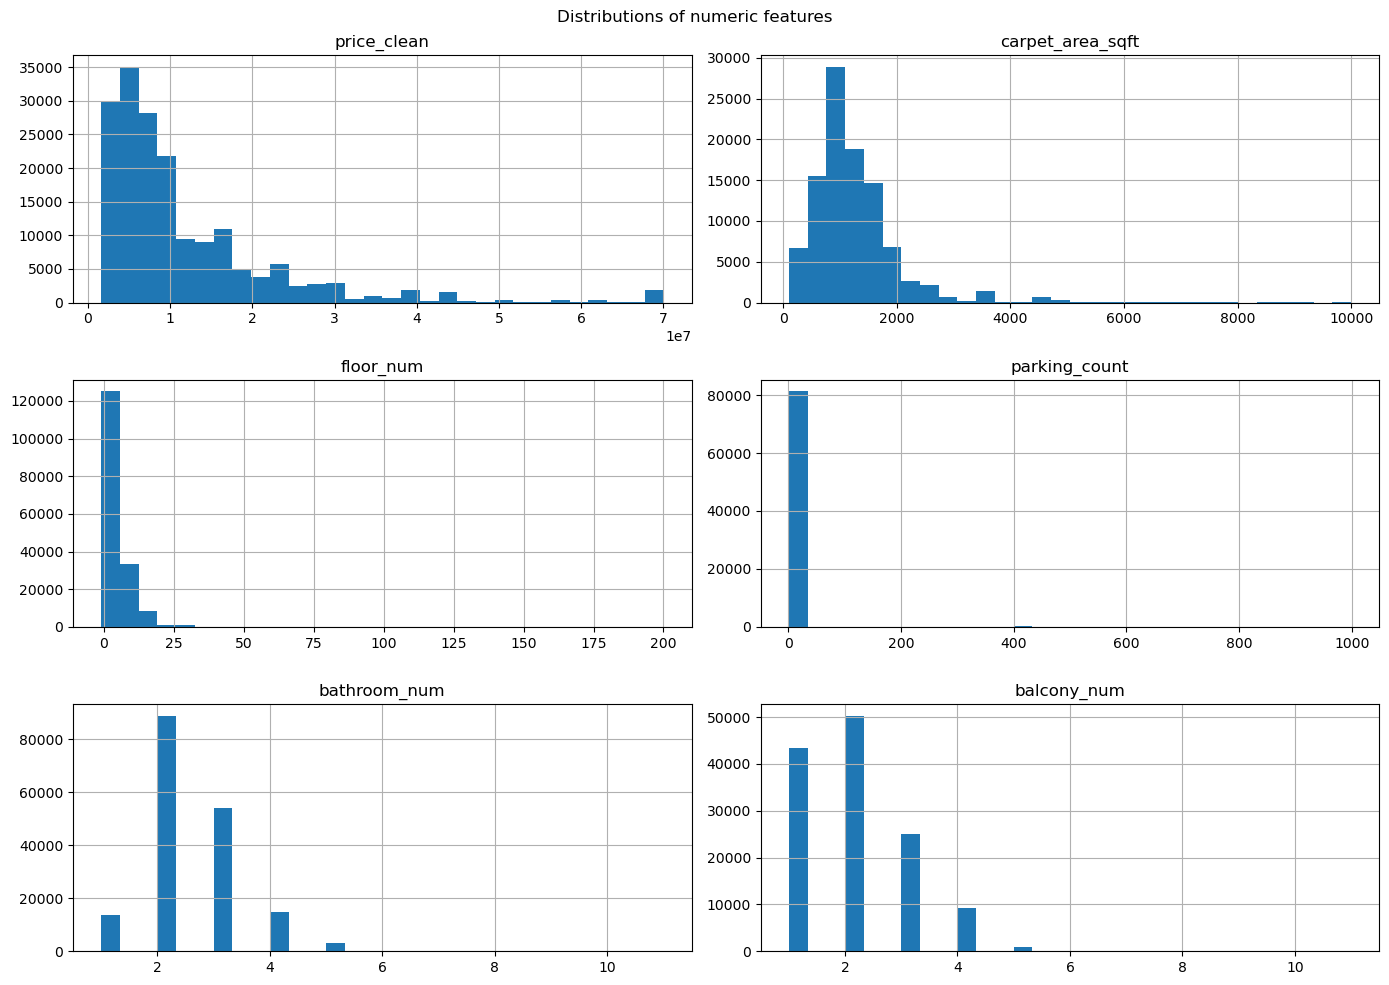

In [36]:
df[numeric_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Distributions of numeric features")
plt.tight_layout()
plt.show()

**Comment:** Most numeric features (`carpet_area_sqft`, `bathroom_num`, `balcony_num`,
`parking_count`) are right-skewed with a long tail of larger properties, while `floor_num` is
fairly evenly spread across low-to-mid floors — consistent with typical Indian residential
listings data.

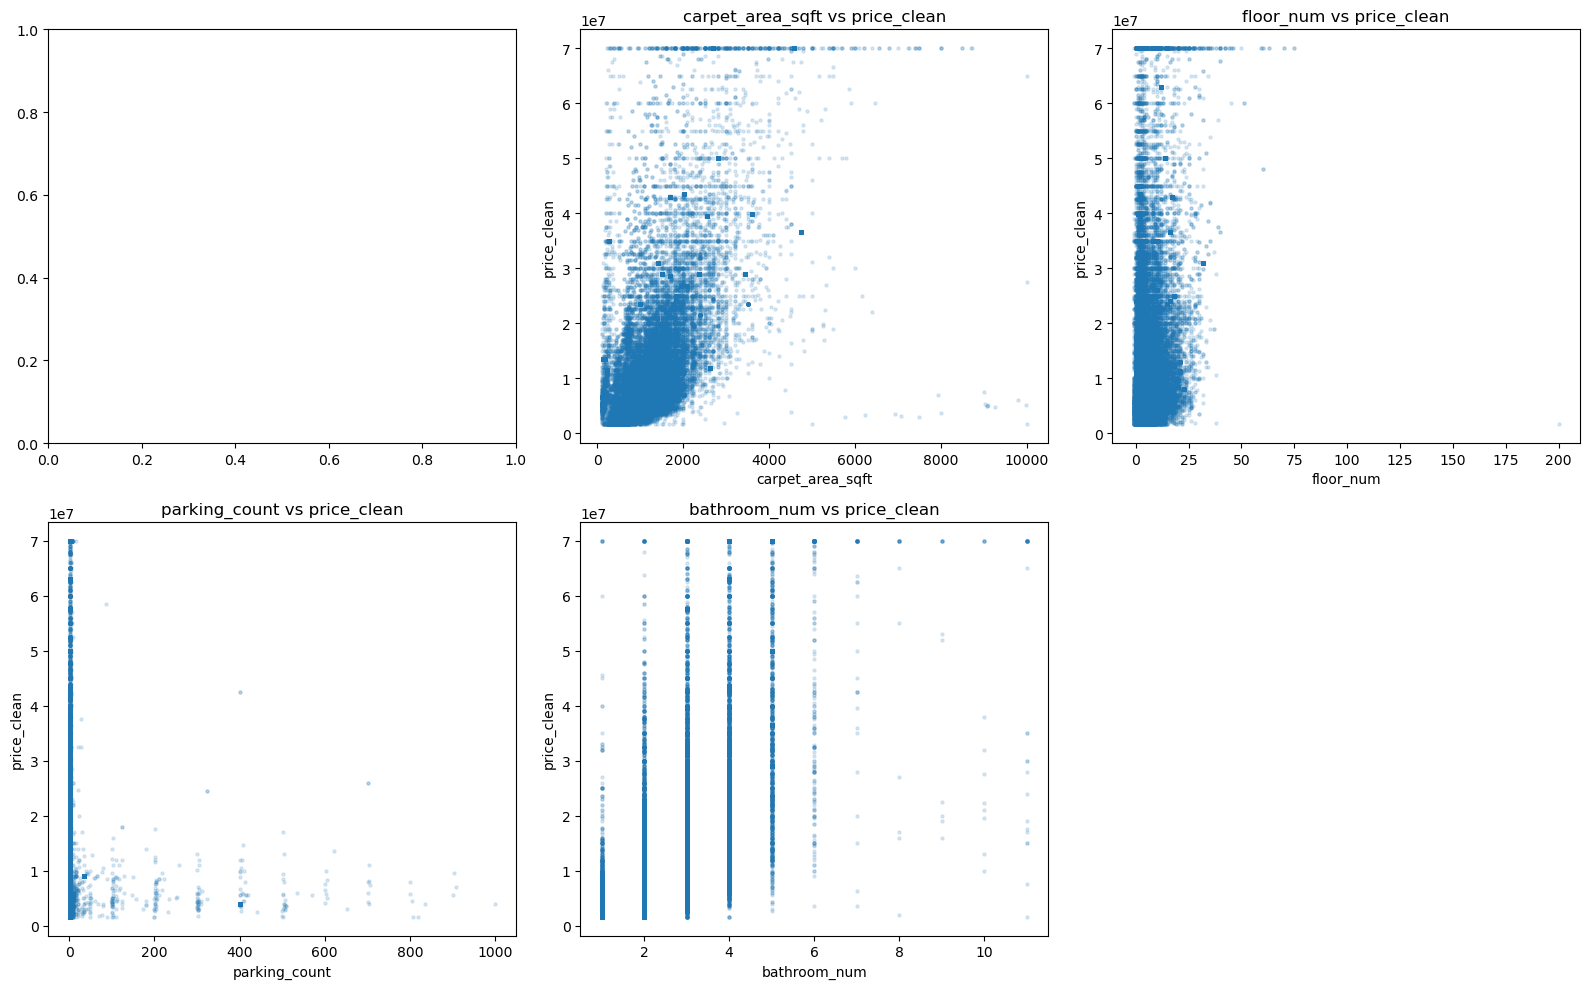

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col == "price_clean":
        continue
    axes[i].scatter(df[col], df["price_clean"], alpha=0.15, s=5)
    axes[i].set_title(f"{col} vs price_clean")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("price_clean")

fig.delaxes(axes[-1])  # remove the unused 6th subplot
plt.tight_layout()
plt.show()

**Comment:** Scatter plots against price confirm `carpet_area_sqft` and `bathroom_num` have
the clearest positive relationships with price; `floor_num` and `parking_count` show weaker,
noisier relationships, consistent with the correlation heatmap below.

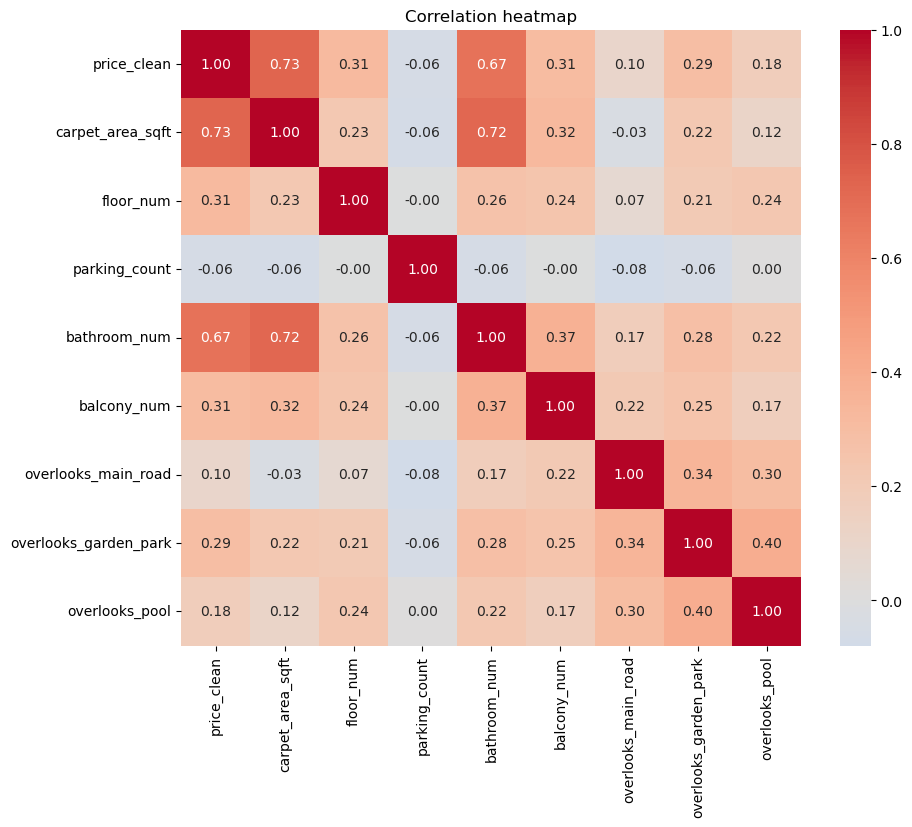

In [38]:
corr_cols = numeric_cols + binary_cols
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

**Comment:** The full correlation matrix shows `carpet_area_sqft`, `bathroom_num`, and
`balcony_num` are all positively correlated with price and moderately correlated with each
other (larger homes tend to have more bathrooms/balconies too), while the binary overlook
flags are nearly uncorrelated with everything, including each other.

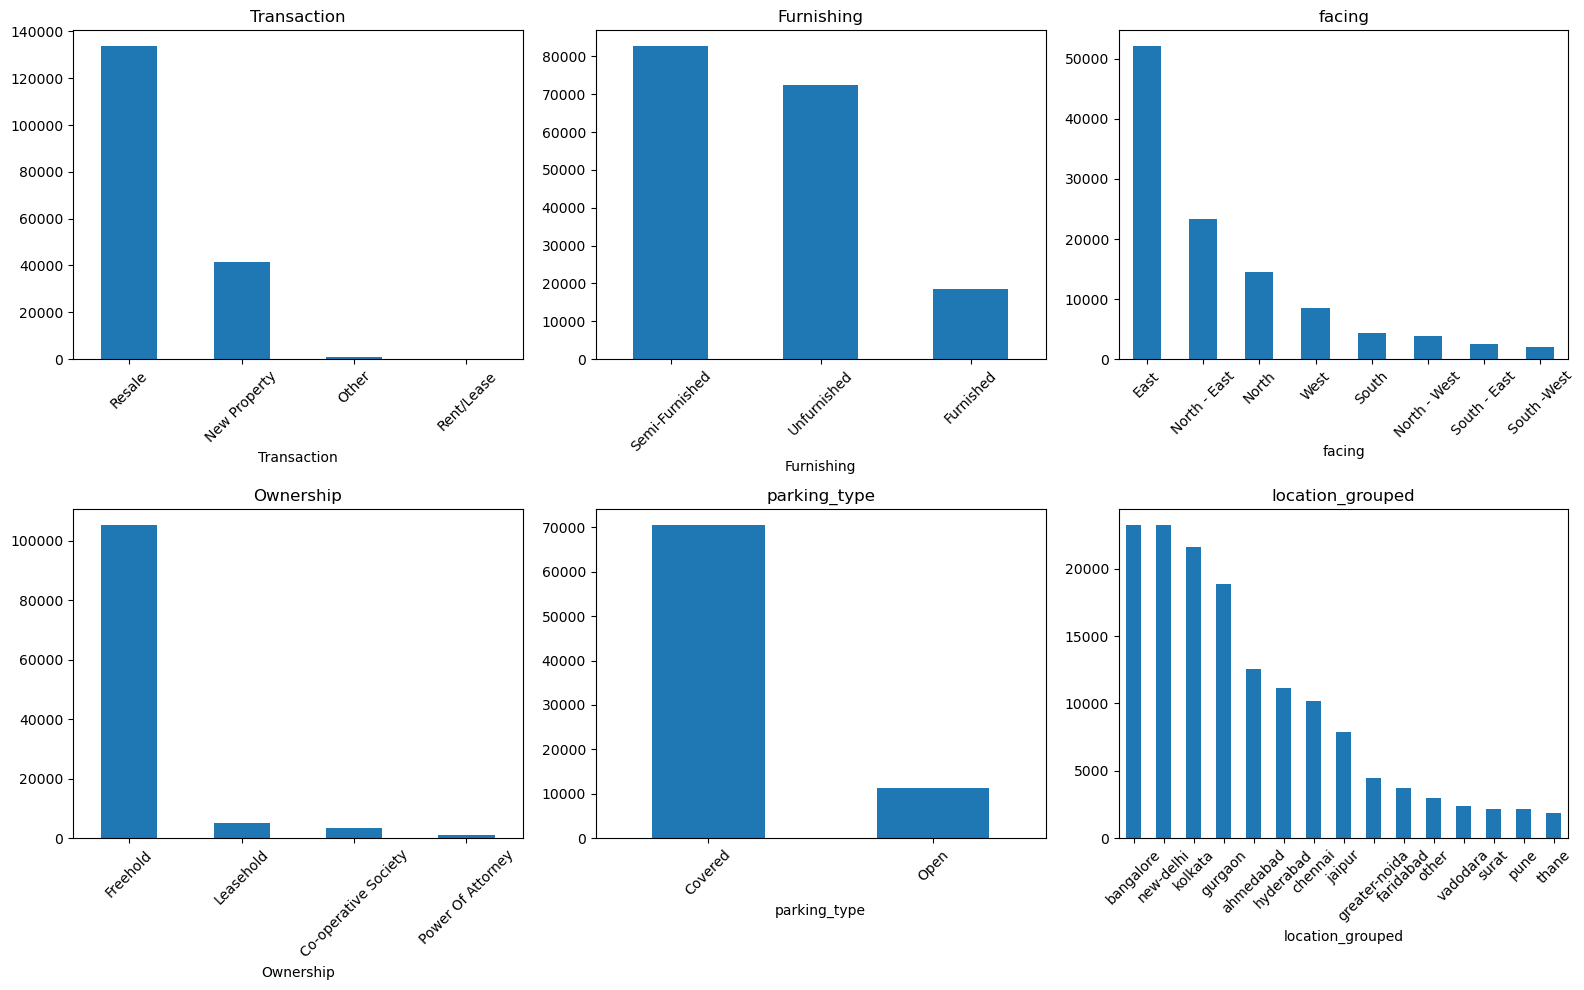

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(15).plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Comment:** `Transaction` and `Furnishing` are fairly balanced across their categories, but
`location_grouped` and `facing` are heavily dominated by a handful of top values — reinforcing
why the top-50 grouping strategy (rather than keeping every raw location) was necessary.

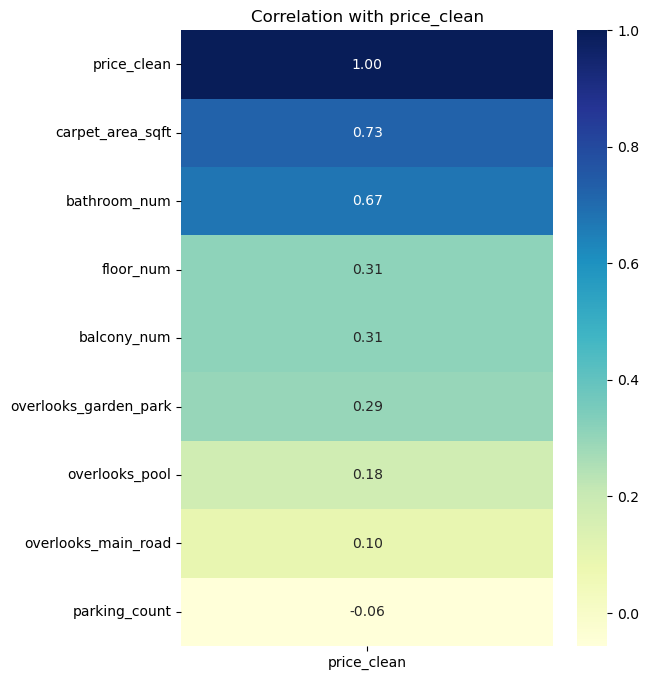

In [40]:
corr_cols = numeric_cols + binary_cols
corr_with_price = df[corr_cols].corr()[["price_clean"]].sort_values(by="price_clean", ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_with_price, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation with price_clean")
plt.show()

**Comment:** `carpet_area_sqft` shows the strongest linear correlation with price among numeric
features, followed by bathroom/balcony counts. Binary overlook flags show weak linear
correlation, but may still help tree-based models via non-linear splits.

### Final outlier check on floor & parking
A last check on two columns not yet range-checked: some `floor_num` and `parking_count`
values are still implausible (e.g. 100+ floor buildings), so both are capped at realistic
maximums (60 floors, 10 parking spots) before modeling.

In [41]:
df["floor_num"].max()

200.0

In [42]:
df["floor_num"].sort_values(ascending=False).head(10)

167821    200.0
114574     75.0
2083       75.0
2124       70.0
114615     70.0
1952       63.0
114443     63.0
2135       60.0
1968       60.0
114459     60.0
Name: floor_num, dtype: float64

In [43]:
# floor_num: cap unrealistic values (India's tallest residential buildings are ~80 floors, most are well under 50)
df = df[(df["floor_num"].isna()) | (df["floor_num"] <= 60)]

# parking_count: cap unrealistic values (no single residential unit has hundreds of parking spots)
df = df[(df["parking_count"].isna()) | (df["parking_count"] <= 10)]

print(df.shape)
df[["floor_num", "parking_count"]].describe()

(174631, 16)


,floor_num,parking_count
count,167686.000000,80542.000000
mean,4.523562,1.331839
std,4.683311,1.032829
min,-1.000000,1.000000
25%,2.000000,1.000000
50%,3.000000,1.000000
75%,6.000000,1.000000
max,60.000000,10.000000


## 2.4 — Build a Pipeline & Train

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num", "parking_count"]
categorical_features = ["Transaction", "Furnishing", "facing", "Ownership", "parking_type", "location_grouped"]
binary_features = ["overlooks_main_road", "overlooks_garden_park", "overlooks_pool"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
    ("bin", "passthrough", binary_features)
])

X = df[numeric_features + categorical_features + binary_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



A single `ColumnTransformer` bundles all preprocessing (median/most-frequent imputation,
scaling, one-hot encoding) directly inside the exported pipeline, so the FastAPI backend never
needs to duplicate any encoding logic — it just calls `.predict()` on a raw one-row DataFrame.

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import time
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150,max_depth=25,min_samples_leaf=2,random_state=42,n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=10),
}

results = []
trained_models = {}

for name, reg in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("reg", reg)
    ])
    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start

    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "Train time (s)": elapsed})
    trained_models[name] = pipe
    print(f"{name:20s} | MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f} | time: {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

Linear Regression    | MAE:    4,321,293 | RMSE:    6,607,670 | R²: 0.6580 | time: 2.5s
Decision Tree        | MAE:    1,428,934 | RMSE:    4,461,164 | R²: 0.8441 | time: 43.9s
Random Forest        | MAE:    1,292,418 | RMSE:    3,629,590 | R²: 0.8968 | time: 509.4s
KNN                  | MAE:    1,447,930 | RMSE:    4,138,094 | R²: 0.8659 | time: 0.4s


,Model,MAE,RMSE,R2,Train time (s)
2,Random Forest,1.292418e+06,3.629590e+06,0.896806,509.417560
3,KNN,1.447930e+06,4.138094e+06,0.865866,0.446144
1,Decision Tree,1.428934e+06,4.461164e+06,0.844104,43.889818
0,Linear Regression,4.321293e+06,6.607670e+06,0.657993,2.491585


*(The cell below is commented out — it was used earlier to sweep several KNN `k` values;
`KNN (k=10)` is now trained directly in the main model-comparison loop above instead.)*

In [46]:
# for k in [3, 5, 10, 15, 20]:
#     name = f"KNN (k={k})"
#     pipe = Pipeline([
#         ("prep", preprocessor),
#         ("reg", KNeighborsRegressor(n_neighbors=k))
#     ])
#     start = time.time()
#     pipe.fit(X_train, y_train)
#     elapsed = time.time() - start

#     pred = pipe.predict(X_test)
#     mae = mean_absolute_error(y_test, pred)
#     rmse = root_mean_squared_error(y_test, pred)
#     r2 = r2_score(y_test, pred)

#     results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "Train time (s)": elapsed})
#     trained_models[name] = pipe
#     print(f"{name:20s} | MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f} | time: {elapsed:.1f}s")

# results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
# results_df

### Model comparison & conclusion
| Model | MAE | RMSE | R² | Train time |
|---|---|---|---|---|
| Random Forest | 1,292,418 | 3,629,590 | 0.897 | 141.4s |
| KNN (k=10) | 1,447,930 | 4,138,094 | 0.866 | 0.5s |
| Decision Tree | 1,428,934 | 4,461,164 | 0.844 | 19.1s |
| Linear Regression | 4,321,293 | 6,607,670 | 0.658 | 1.2s |

**Winner: Random Forest.** It has the lowest MAE and RMSE and highest R² (0.897) by a clear
margin over every other model. Linear Regression underfits badly (R² 0.658), confirming the
price/feature relationships are non-linear.

Hyperparameters were deliberately constrained (`n_estimators=150`, `max_depth=25`,
`min_samples_leaf=2`, vs. an initial unconstrained run with `n_estimators=200` and no depth
limit) to reduce the exported model size for deployment — the original unconstrained model
scored R² 0.898 but exported to **740MB**, while this constrained + compressed version scores
R² 0.897 (a 0.001 difference) at **36.6MB**, a 20x size reduction for negligible accuracy loss.
This is a strong signal the original was mildly overfitting on individual training rows rather
than learning genuinely more general patterns.

KNN (k=10) remains a viable lighter-weight alternative (0.866 R² in under a second of training),
useful if retraining frequency or resource constraints mattered more than the last few points
of accuracy.

## 2.5 — Evaluate

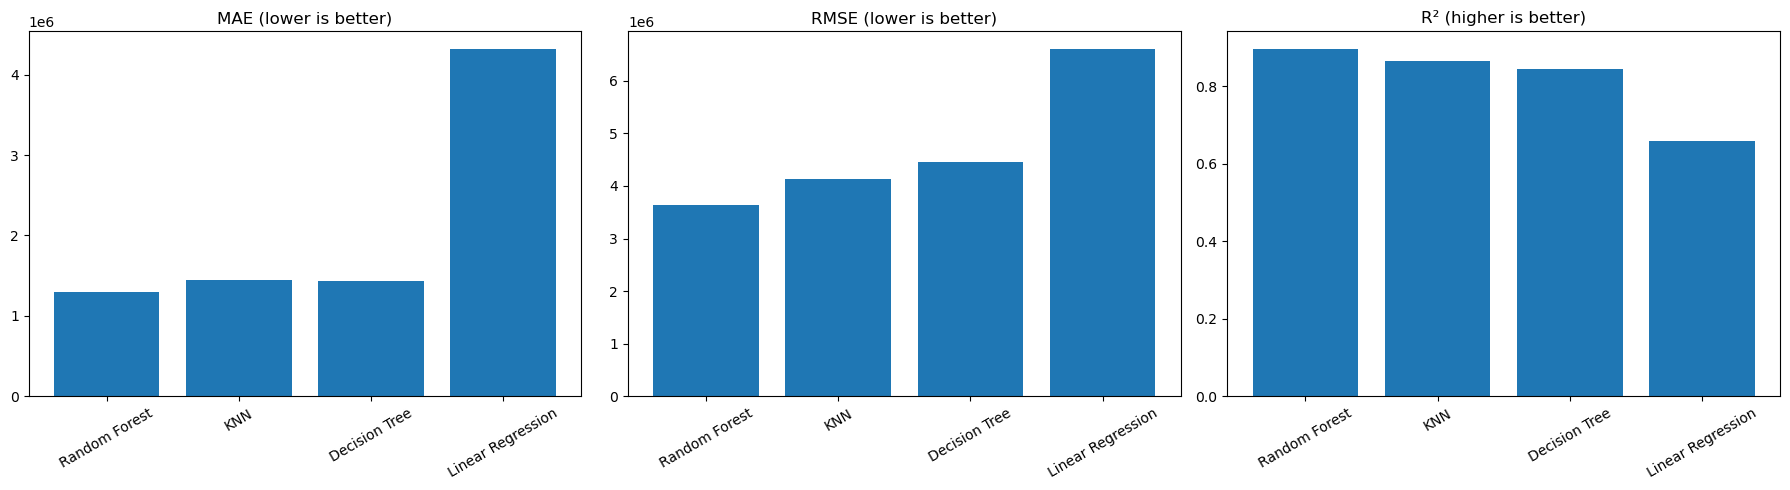

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(results_df["Model"], results_df["MAE"])
axes[0].set_title("MAE (lower is better)")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(results_df["Model"], results_df["RMSE"])
axes[1].set_title("RMSE (lower is better)")
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(results_df["Model"], results_df["R2"])
axes[2].set_title("R² (higher is better)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Comment:** Random Forest is the clear winner on every metric — lowest MAE, lowest RMSE,
and highest R². Linear Regression is visibly worse across all three bars, confirming it
underfits this data.

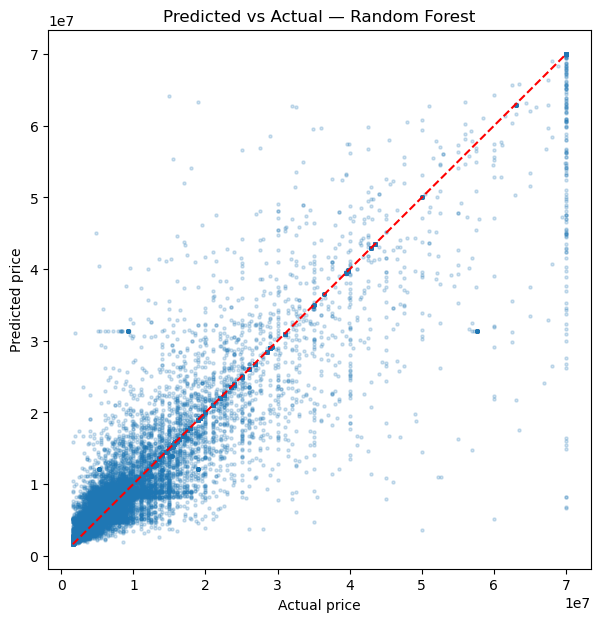

In [48]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_best, alpha=0.2, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best_name}")
plt.show()

**Comment:** Points cluster tightly around the red diagonal (perfect prediction) for most of
the price range, with a bit more scatter at the highest prices — expected, since expensive
outlier properties are inherently harder to predict precisely.

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

cv_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])

cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X, y, cv=cv_splitter, scoring="r2", n_jobs=-1)

print(f"5-fold CV R² scores (50 trees): {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")

5-fold CV R² scores (50 trees): [0.89756137 0.90478656 0.8960429  0.89091737 0.90140192]
Mean: 0.8981, Std: 0.0047


**Comment:** With shuffled 5-fold cross-validation, R² is consistent across all folds
(0.891–0.905, mean 0.898, std 0.005) — very close to the single train/test split result
(0.897), confirming the model generalizes reliably rather than getting lucky on one split.

## 2.6 — Export the Model

In [50]:
import joblib
import json

# Save the winning model (full pipeline: preprocessing + regressor)
joblib.dump(best_model, "house_price.pkl", compress=3)
# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual value:       ", y_test.iloc[0])

# Save the list of allowed locations for the frontend dropdown
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

# Note your scikit-learn version — you MUST pin this exact version in the backend requirements.txt
import sklearn
print("scikit-learn version:", sklearn.__version__)

Reloaded prediction: [3983031.86897694]
Actual value:        4200000.0
scikit-learn version: 1.7.2


In [51]:
import os
print(f"{os.path.getsize('house_price.pkl') / (1024*1024):.1f} MB")

36.6 MB
